In [1]:
import numpy as np 
import pandas as pd 


In [2]:
df=pd.read_csv('datasets/retail_store_sales.csv')
df.head(10)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
5,TXN_7482416,CUST_09,Patisserie,NaN,NaN,10.0,200.0,Credit Card,Online,2023-11-30,NaN
6,TXN_3652209,CUST_07,Food,Item_1_FOOD,5.0,8.0,40.0,Credit Card,In-store,2023-06-10,True
7,TXN_1372952,CUST_21,Furniture,NaN,33.5,NaN,NaN,Digital Wallet,In-store,2024-04-02,True
8,TXN_9728486,CUST_23,Furniture,Item_16_FUR,27.5,1.0,27.5,Credit Card,In-store,2023-04-26,False
9,TXN_2722661,CUST_25,Butchers,Item_22_BUT,36.5,3.0,109.5,Cash,Online,2024-03-14,False


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  str    
 1   Customer ID       12575 non-null  str    
 2   Category          12575 non-null  str    
 3   Item              11362 non-null  str    
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  str    
 8   Location          12575 non-null  str    
 9   Transaction Date  12575 non-null  str    
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(1), str(7)
memory usage: 1.9+ MB


In [4]:
df=df.drop_duplicates()

In [5]:
df['Category'].unique()

<ArrowStringArray>
[                        'Patisserie',                      'Milk Products',
                           'Butchers',                          'Beverages',
                               'Food',                          'Furniture',
      'Electric household essentials', 'Computers and electric accessories']
Length: 8, dtype: str

In [6]:
df.isnull().sum()

Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64

In [7]:
# df[df['Category'] =='Patisserie']['Price Per Unit'].mean()

In [8]:
# Step 1: Calculate mean of Patisserie's Price Per Unit (ignores NaN automatically)
# patisserie_mean = df[df['Category'] == 'Patisserie']['Price Per Unit'].mean()

# # Step 2: Fill NaN values only for Patisserie rows using .loc
# df.loc[(df['Category'] == 'Patisserie') & (df['Price Per Unit'].isna()), 'Price Per Unit'] = patisserie_mean

In [9]:
# df['Price Per Unit'] = df.groupby('Category')['Price Per Unit'].transform(
#     # lambda x: x.fillna(x.mean())
# )

In [10]:
df.head(10)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
5,TXN_7482416,CUST_09,Patisserie,NaN,NaN,10.0,200.0,Credit Card,Online,2023-11-30,NaN
6,TXN_3652209,CUST_07,Food,Item_1_FOOD,5.0,8.0,40.0,Credit Card,In-store,2023-06-10,True
7,TXN_1372952,CUST_21,Furniture,NaN,33.5,NaN,NaN,Digital Wallet,In-store,2024-04-02,True
8,TXN_9728486,CUST_23,Furniture,Item_16_FUR,27.5,1.0,27.5,Credit Card,In-store,2023-04-26,False
9,TXN_2722661,CUST_25,Butchers,Item_22_BUT,36.5,3.0,109.5,Cash,Online,2024-03-14,False


In [11]:
df[df['Category']=='Milk Products']['Item'].isna().sum()

np.int64(159)

In [12]:
df[df['Category']=='Milk Products']['Item'].str.endswith('MILK').sum()

np.int64(1425)

In [13]:
df.dropna(subset=['Item'], inplace=True)

In [14]:
df.isnull().sum()

Transaction ID         0
Customer ID            0
Category               0
Item                   0
Price Per Unit         0
Quantity               0
Total Spent            0
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    3783
dtype: int64

In [15]:
df.head(20)


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
6,TXN_3652209,CUST_07,Food,Item_1_FOOD,5.0,8.0,40.0,Credit Card,In-store,2023-06-10,True
8,TXN_9728486,CUST_23,Furniture,Item_16_FUR,27.5,1.0,27.5,Credit Card,In-store,2023-04-26,False
9,TXN_2722661,CUST_25,Butchers,Item_22_BUT,36.5,3.0,109.5,Cash,Online,2024-03-14,False
10,TXN_8776416,CUST_22,Butchers,Item_3_BUT,8.0,9.0,72.0,Cash,In-store,2024-12-14,True
12,TXN_5874772,CUST_23,Food,Item_2_FOOD,6.5,7.0,45.5,Cash,Online,2023-09-09,True


In [16]:
df=df.drop(columns=['Transaction ID','Customer ID'])

In [17]:
df[['Discount Applied', 'Price Per Unit']].corr()

,Discount Applied,Price Per Unit
Discount Applied,1.000000,0.006295
Price Per Unit,0.006295,1.000000


<Axes: xlabel='Discount Applied', ylabel='Price Per Unit'>

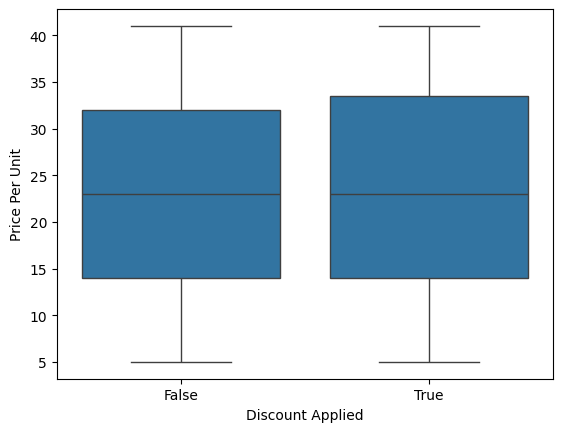

In [18]:
import seaborn as sns
sns.boxplot(x='Discount Applied', y='Price Per Unit', data=df)

In [19]:
(df['Discount Applied'].isna().sum()/len(df))

np.float64(0.3329519450800915)

In [20]:
df['Discount Applied'] = df['Discount Applied'].map({True:1, False:0}).fillna(0).astype(int)

In [21]:
df

,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,1
1,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,1
2,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,0
3,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,0
4,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,0
...,...,...,...,...,...,...,...,...,...
12570,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,0
12571,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,0
12572,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,0
12573,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,1


In [22]:
df['Category'].unique()

<ArrowStringArray>
[                        'Patisserie',                      'Milk Products',
                           'Butchers',                          'Beverages',
                               'Food',                          'Furniture',
      'Electric household essentials', 'Computers and electric accessories']
Length: 8, dtype: str

In [23]:
from sklearn.preprocessing import OneHotEncoder

In [24]:
ohe=OneHotEncoder()

In [25]:
df_new=pd.get_dummies(df,columns=['Category'],drop_first=True,dtype=int)

In [26]:
df_new

,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Category_Butchers,Category_Computers and electric accessories,Category_Electric household essentials,Category_Food,Category_Furniture,Category_Milk Products,Category_Patisserie
0,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,1,0,0,0,0,0,0,1
1,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,1,0,0,0,0,0,1,0
2,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,0,1,0,0,0,0,0,0
3,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,0,0,0,0,0,0,0,0
4,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12570,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,0,0,0,0,0,0,0,1
12571,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,0,0,0,0,0,0,0,0
12572,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,0,1,0,0,0,0,0,0
12573,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,1,0,0,0,0,1,0,0


In [27]:
df_new['Quantity']=df_new['Quantity'].astype(int)

In [28]:
df['item_code']=df['Item'].str.split("_").str[1]

In [29]:
df['Products']=df['Item'].str.split("_").str[2]

In [30]:
df

,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,item_code,Products
0,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,1,10,PAT
1,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,1,17,MILK
2,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,0,12,BUT
3,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,0,16,BEV
4,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,0,6,FOOD
...,...,...,...,...,...,...,...,...,...,...,...
12570,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,0,23,PAT
12571,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,0,2,BEV
12572,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,0,7,BUT
12573,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,1,7,FUR


In [31]:
df['item_code']=df['item_code'].astype(int)

In [32]:
df['Location']=df['Location'].map({'Online':1,'In-store':0})

In [33]:
df.info()

<class 'pandas.DataFrame'>
Index: 11362 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Category          11362 non-null  str    
 1   Item              11362 non-null  str    
 2   Price Per Unit    11362 non-null  float64
 3   Quantity          11362 non-null  float64
 4   Total Spent       11362 non-null  float64
 5   Payment Method    11362 non-null  str    
 6   Location          11362 non-null  int64  
 7   Transaction Date  11362 non-null  str    
 8   Discount Applied  11362 non-null  int64  
 9   item_code         11362 non-null  int64  
 10  Products          11362 non-null  object 
dtypes: float64(3), int64(3), object(1), str(4)
memory usage: 1.5+ MB


In [34]:
df['Payment Method'].unique()

<ArrowStringArray>
['Digital Wallet', 'Credit Card', 'Cash']
Length: 3, dtype: str

In [35]:
df['Payment Method']=df['Payment Method'].map({'Digital Wallet':1,'Credit Card':2,'Cash':3})

In [36]:
df=pd.get_dummies(df,columns=['Category'],drop_first=True,dtype=int)

In [37]:
df

,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,item_code,Products,Category_Butchers,Category_Computers and electric accessories,Category_Electric household essentials,Category_Food,Category_Furniture,Category_Milk Products,Category_Patisserie
0,Item_10_PAT,18.5,10.0,185.0,1,1,2024-04-08,1,10,PAT,0,0,0,0,0,0,1
1,Item_17_MILK,29.0,9.0,261.0,1,1,2023-07-23,1,17,MILK,0,0,0,0,0,1,0
2,Item_12_BUT,21.5,2.0,43.0,2,1,2022-10-05,0,12,BUT,1,0,0,0,0,0,0
3,Item_16_BEV,27.5,9.0,247.5,2,1,2022-05-07,0,16,BEV,0,0,0,0,0,0,0
4,Item_6_FOOD,12.5,7.0,87.5,1,1,2022-10-02,0,6,FOOD,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12570,Item_23_PAT,38.0,4.0,152.0,2,0,2023-09-03,0,23,PAT,0,0,0,0,0,0,1
12571,Item_2_BEV,6.5,9.0,58.5,3,1,2022-08-12,0,2,BEV,0,0,0,0,0,0,0
12572,Item_7_BUT,14.0,10.0,140.0,3,1,2024-08-24,0,7,BUT,1,0,0,0,0,0,0
12573,Item_7_FUR,14.0,6.0,84.0,3,1,2023-12-30,1,7,FUR,0,0,0,0,1,0,0


In [38]:
df['Quantity']=df['Quantity'].astype(int)

In [39]:
df=df.drop(columns=['Item'])

In [40]:
df

,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,item_code,Products,Category_Butchers,Category_Computers and electric accessories,Category_Electric household essentials,Category_Food,Category_Furniture,Category_Milk Products,Category_Patisserie
0,18.5,10,185.0,1,1,2024-04-08,1,10,PAT,0,0,0,0,0,0,1
1,29.0,9,261.0,1,1,2023-07-23,1,17,MILK,0,0,0,0,0,1,0
2,21.5,2,43.0,2,1,2022-10-05,0,12,BUT,1,0,0,0,0,0,0
3,27.5,9,247.5,2,1,2022-05-07,0,16,BEV,0,0,0,0,0,0,0
4,12.5,7,87.5,1,1,2022-10-02,0,6,FOOD,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12570,38.0,4,152.0,2,0,2023-09-03,0,23,PAT,0,0,0,0,0,0,1
12571,6.5,9,58.5,3,1,2022-08-12,0,2,BEV,0,0,0,0,0,0,0
12572,14.0,10,140.0,3,1,2024-08-24,0,7,BUT,1,0,0,0,0,0,0
12573,14.0,6,84.0,3,1,2023-12-30,1,7,FUR,0,0,0,0,1,0,0


In [41]:
df['Transaction year']=df['Transaction Date'].str.split("-").str[0]

In [42]:
df['Transaction month']=df['Transaction Date'].str.split("-").str[1]

In [43]:
df['Transaction date']=df['Transaction Date'].str.split("-").str[2]

In [44]:
df

,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,item_code,Products,Category_Butchers,Category_Computers and electric accessories,Category_Electric household essentials,Category_Food,Category_Furniture,Category_Milk Products,Category_Patisserie,Transaction year,Transaction month,Transaction date
0,18.5,10,185.0,1,1,2024-04-08,1,10,PAT,0,0,0,0,0,0,1,2024,04,08
1,29.0,9,261.0,1,1,2023-07-23,1,17,MILK,0,0,0,0,0,1,0,2023,07,23
2,21.5,2,43.0,2,1,2022-10-05,0,12,BUT,1,0,0,0,0,0,0,2022,10,05
3,27.5,9,247.5,2,1,2022-05-07,0,16,BEV,0,0,0,0,0,0,0,2022,05,07
4,12.5,7,87.5,1,1,2022-10-02,0,6,FOOD,0,0,0,1,0,0,0,2022,10,02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12570,38.0,4,152.0,2,0,2023-09-03,0,23,PAT,0,0,0,0,0,0,1,2023,09,03
12571,6.5,9,58.5,3,1,2022-08-12,0,2,BEV,0,0,0,0,0,0,0,2022,08,12
12572,14.0,10,140.0,3,1,2024-08-24,0,7,BUT,1,0,0,0,0,0,0,2024,08,24
12573,14.0,6,84.0,3,1,2023-12-30,1,7,FUR,0,0,0,0,1,0,0,2023,12,30


In [45]:
df.drop(columns=['Transaction Date'],inplace=True)

In [46]:
df.info()

<class 'pandas.DataFrame'>
Index: 11362 entries, 0 to 12574
Data columns (total 18 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Price Per Unit                               11362 non-null  float64
 1   Quantity                                     11362 non-null  int64  
 2   Total Spent                                  11362 non-null  float64
 3   Payment Method                               11362 non-null  int64  
 4   Location                                     11362 non-null  int64  
 5   Discount Applied                             11362 non-null  int64  
 6   item_code                                    11362 non-null  int64  
 7   Products                                     11362 non-null  object 
 8   Category_Butchers                            11362 non-null  int64  
 9   Category_Computers and electric accessories  11362 non-null  int64  
 10  Category_Elect

In [47]:
df['Transaction year']=df['Transaction year'].astype(int)

In [48]:
df['Transaction month']=df['Transaction month'].astype(int)

In [49]:
df['Transaction date']=df['Transaction date'].astype(int)

<Axes: xlabel='Products', ylabel='count'>

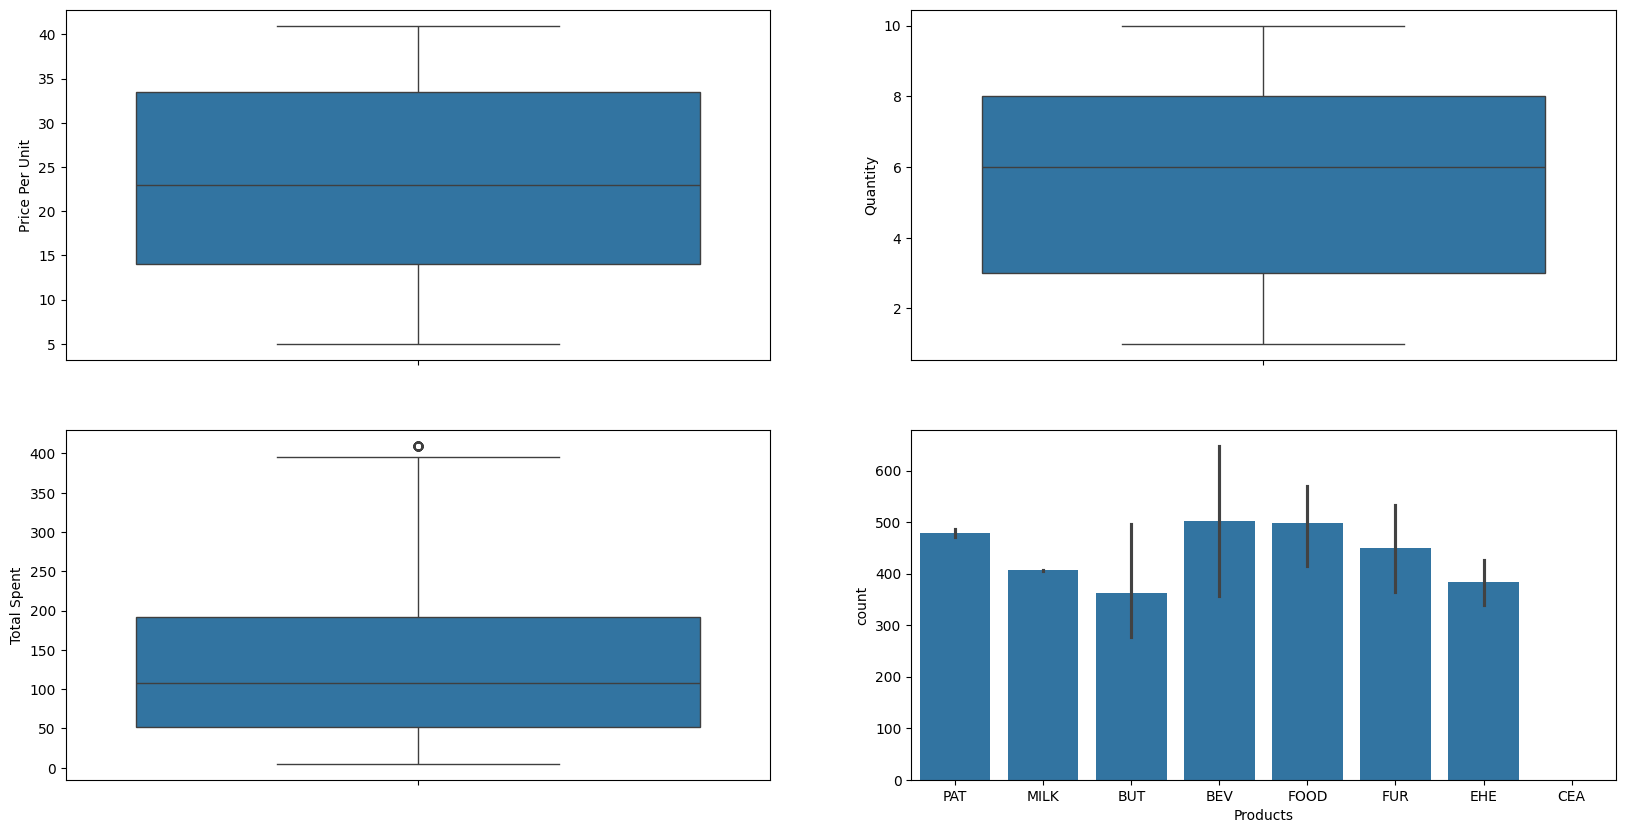

In [50]:
import matplotlib.pyplot as plt 
fig, axes = plt.subplots(2, 2, figsize=(20, 10))

sns.boxplot(df['Price Per Unit'],ax=axes[0][0])
sns.boxplot(df['Quantity'],ax=axes[0][1])
sns.boxplot(df['Total Spent'],ax=axes[1][0])
sns.barplot(y=df['item_code'].value_counts(),x=df['Products'], ax=axes[1][1])

<Axes: xlabel='Products', ylabel='count'>

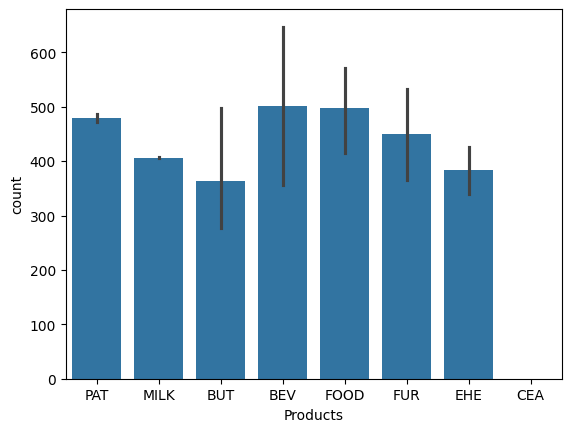

In [51]:
sns.barplot(y=df['item_code'].value_counts(),x=df['Products'])

In [52]:
df.describe()

,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Discount Applied,item_code,Category_Butchers,Category_Computers and electric accessories,Category_Electric household essentials,Category_Food,Category_Furniture,Category_Milk Products,Category_Patisserie,Transaction year,Transaction month,Transaction date
count,11362.000000,11362.000000,11362.000000,11362.000000,11362.000000,11362.000000,11362.000000,11362.000000,11362.000000,11362.000000,11362.000000,11362.000000,11362.000000,11362.000000,11362.000000,11362.000000,11362.000000
mean,23.356847,5.535029,129.642537,2.017691,0.505633,0.334536,13.237898,0.125066,0.122954,0.126474,0.125506,0.128499,0.125418,0.120489,2023.042158,6.370709,15.613096
std,10.736030,2.855166,94.662368,0.819480,0.499990,0.471849,7.157353,0.330808,0.328399,0.332398,0.331306,0.334659,0.331207,0.325547,0.855290,3.498419,8.805856
min,5.000000,1.000000,5.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2022.000000,1.000000,1.000000
25%,14.000000,3.000000,52.000000,1.000000,0.000000,0.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2022.000000,3.000000,8.000000
50%,23.000000,6.000000,108.500000,2.000000,1.000000,0.000000,13.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2023.000000,6.000000,15.000000
75%,33.500000,8.000000,192.000000,3.000000,1.000000,1.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2024.000000,9.000000,23.000000
max,41.000000,10.000000,410.000000,3.000000,1.000000,1.000000,25.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2025.000000,12.000000,31.000000


C:\Users\shankar dixit\AppData\Local\Temp\ipykernel_14260\3329924333.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Total Spent'])


<Axes: xlabel='Total Spent', ylabel='Density'>

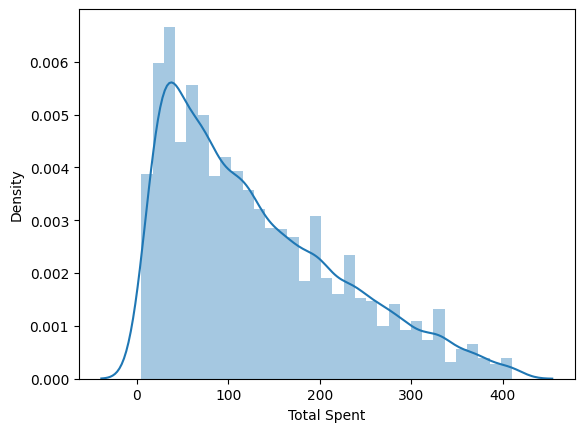

In [53]:
sns.distplot(df['Total Spent'])

C:\Users\shankar dixit\AppData\Local\Temp\ipykernel_14260\3003943703.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Price Per Unit'])


<Axes: xlabel='Price Per Unit', ylabel='Density'>

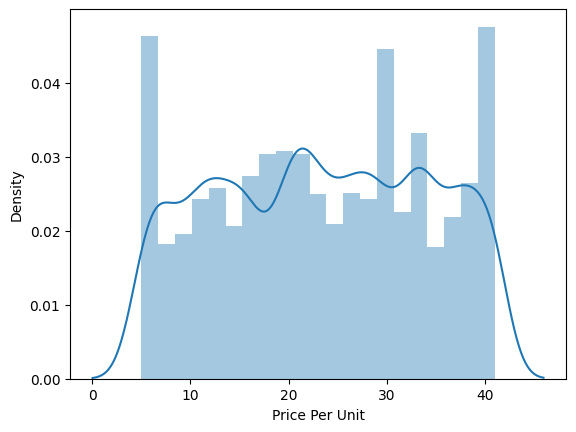

In [54]:
sns.distplot(df['Price Per Unit'])

In [55]:
df.sample(10)

,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Discount Applied,item_code,Products,Category_Butchers,Category_Computers and electric accessories,Category_Electric household essentials,Category_Food,Category_Furniture,Category_Milk Products,Category_Patisserie,Transaction year,Transaction month,Transaction date
5207,26.0,10,260.0,1,1,0,15,BEV,0,0,0,0,0,0,0,2024,2,28
5407,6.5,6,39.0,2,0,0,2,CEA,0,1,0,0,0,0,0,2022,12,7
8165,41.0,9,369.0,1,1,1,25,FUR,0,0,0,0,1,0,0,2022,7,11
550,15.5,5,77.5,1,1,0,8,EHE,0,0,1,0,0,0,0,2024,5,1
427,27.5,8,220.0,1,1,1,16,MILK,0,0,0,0,0,1,0,2024,4,27
10115,29.0,6,174.0,3,0,0,17,EHE,0,0,1,0,0,0,0,2024,1,8
10508,6.5,4,26.0,1,0,0,2,MILK,0,0,0,0,0,1,0,2022,6,4
4131,18.5,5,92.5,3,0,0,10,CEA,0,1,0,0,0,0,0,2024,9,29
8114,41.0,7,287.0,3,1,0,25,FOOD,0,0,0,1,0,0,0,2022,3,17
3259,17.0,7,119.0,2,1,0,9,CEA,0,1,0,0,0,0,0,2023,9,28


In [56]:
multi=x.corr()

NameError: name 'x' is not defined

In [ ]:
sns.heatmap(multi,cmap='coolwarm')

In [ ]:
 monthly=df.groupby('Transaction month')['Total Spent'].sum().reset_index()

In [ ]:
sns.barplot(data=monthly,x=('Transaction month'),y=('Total Spent'))

In [ ]:
yearly=df.groupby('Transaction year')['Total Spent'].sum().reset_index()

In [ ]:
sns.barplot(data=yearly,x=('Transaction year'),y=('Total Spent'))

In [ ]:
prodcutly=df.groupby('Products')['Total Spent'].sum().reset_index()

In [ ]:
# Group by both columns and sum the spending
grouped_df = df.groupby(['Transaction month', 'Products'])['Total Spent'].sum().reset_index()

sns.barplot(data=grouped_df,x='Products',y='Total Spent',hue='Transaction month')

In [ ]:
df['Total Spent'] = df['Quantity'] * df['Price Per Unit']

In [ ]:
df

In [ ]:
df=pd.get_dummies(df,columns=['Products'],dtype=int)

In [ ]:
df

In [ ]:
x=df.drop(columns=['Total Spent'])
y=df['Total Spent']

In [ ]:
y

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3)

In [ ]:
from sklearn.compose import ColumnTransformer

In [ ]:
# preprocessor=ColumnTransformer( 
#     transformers=[
#         ('tnf1',OneHotEncoder(handle_unknown='ignore'),['Products'])],
#     remainder='passthrough')

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

In [ ]:
from sklearn.tree import DecisionTreeRegressor

In [ ]:
pipeline_lr = Pipeline([
    
    ('model', LinearRegression())
])
pipeline_dt = Pipeline([
    
    ('model', DecisionTreeRegressor())
])
pipelines={
     'Linear Regression': pipeline_lr,
    'dtree': pipeline_dt
}

In [ ]:
from sklearn.metrics import r2_score


In [ ]:
score={}
for name,pipe in pipelines.items():
    pipe.fit(x_train,y_train)
    pred= pipe.predict(x_test)
    score[name]=r2_score(y_test,pred)
    
for name,score in score.items():
    print(f"{name} :{score:.4f}")

In [ ]:
train_pred= pipeline_dt.predict(x_train)

In [ ]:
print(r2_score(y_train,train_pred))

In [ ]:
train_pred2= pipeline_lr.predict(x_train)

In [ ]:
print(r2_score(y_train,train_pred2))

In [ ]:
# model_lr=LinearRegression()
# model_lr.fit(x_train,y_train)
# predictions = model_lr.predict(x_test)

# # Plot actual vs predicted values
# plt.figure(figsize=(6, 6))
# sns.scatterplot(x=y_test, y=predictions, alpha=0.7)

# # Draw the ideal comparison line
# plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
# plt.title('Regression: Actual vs Predicted (No Pipeline)')
# plt.xlabel('Actual Total Spent')
# plt.ylabel('Predicted Total Spent')
# plt.show()

In [ ]:
lr=LinearRegression()

In [ ]:
lr.fit(x_train,y_train)

In [ ]:
predi=lr.predict(x_test)

In [ ]:
coef=lr.coef_

In [ ]:
inter=lr.intercept_

In [ ]:
for col,wei in zip(x_train.columns,coef):
    print(f" weights for   {col}: {wei:.2f}")